#### Notebook to process raw MODIS X-day LAI to annual LAI cycle by vegetation type
The data is extracted from Google Earth Engine (GEE) for locations with vegetation types of interest.
Since we have no certainty on the exact vegetation for each point, we extract LAI for multiple points with the same vegetation type and average it per timestep. This hopefully averages out any errors. For each vegetation type the points must be far enough from each other (e.g. different countries) but should fall in the same climate class e.g. temperate, tropical etc. Since the model uses the LAI values to compute evapotranspiration, it is essential to extract vegetation types which are relevant (at least climatewise) to the area of study.

In [9]:
import numpy as np
import pandas as pd
import os

In [ ]:
def process_modisLAI(modis_LAI_df: pd.DataFrame,
                     lai_col: str = "LAI",
                     scale: float = 1.0,
                     min_obs_per_doy: int = 1) -> pd.Series:
    """
    Build long-term mean annual LAI cycle (DOY 1..366) from a LAI time series table
    and interpolate to daily values. Robust to missing dates / NaNs.

    Returns: pd.Series indexed by doy 1..366
    """
    df = modis_LAI_df.copy()

    # Ensure datetime index
    df.index = pd.to_datetime(df.index, dayfirst=True, errors="raise")

    if lai_col not in df.columns:
        raise ValueError(f"Expected column '{lai_col}'. Found: {list(df.columns)}")

    # numeric + scale
    df[lai_col] = pd.to_numeric(df[lai_col], errors="coerce") * scale

    # Drop missing LAI values (MODIS gaps are normal)
    df = df.dropna(subset=[lai_col])
    if df.empty:
        raise ValueError("All LAI values are NaN after coercion/scaling. Check input column and scaling.")

    # DOY mean climatology
    df["doy"] = df.index.dayofyear
    # optionally require enough observations per doy
    doy_stats = df.groupby("doy")[lai_col].agg(["mean", "count"])
    doy_mean = doy_stats["mean"]
    doy_mean = doy_mean[doy_stats["count"] >= min_obs_per_doy]

    # Need DOY 1 as an anchor for wrap-around
    if 1 not in doy_mean.index:
        # fallback: use the first available DOY as an anchor
        first_doy = int(doy_mean.index.min())
        doy_mean.loc[1] = doy_mean.loc[first_doy]
        doy_mean = doy_mean.sort_index()

    # Add DOY 366 if missing (wrap-around continuity)
    if 366 not in doy_mean.index:
        doy_mean.loc[366] = doy_mean.loc[1]

    # Reindex and interpolate gaps across DOY space
    lai_annual_cycle = doy_mean.sort_index().reindex(np.arange(1, 367)).interpolate("linear")

    # If still NaNs at edges (can happen if early DOYs missing), fill
    lai_annual_cycle = lai_annual_cycle.ffill().bfill()
    lai_annual_cycle.name = "LAI_doy"
    return lai_annual_cycle


In [ ]:
#parent directory
p_dir = os.path.dirname(os.getcwd())
lai_df = pd.read_csv(f'{p_dir}/input/lai/MODIS_MCD15A3H_LAI_500m_IGBP.csv', parse_dates=['date'])

# group lai by landcover class and date
landcover = lai_df['landcover'].unique()

#group by landcover class
lai_veg_cycles = {}
for lc in landcover:
    lai_df_lc = lai_df[lai_df['landcover'] == lc]

    #group by date and calculate mean LAI for each date
    lai_mean= lai_df_lc.groupby('date').mean(numeric_only=True)[['LAI']]
    df_annual = process_modisLAI(lai_mean, lai_col='LAI', scale=1.0)
    lai_smoothed = df_annual.rolling(window=15, center=True, min_periods=1).mean()

    lai_veg_cycles[lc] = lai_smoothed

    #convert to DataFrame for easier plotting
    lai_veg_cycles_df = pd.DataFrame(lai_veg_cycles)

In [16]:
lai_dir = f'{p_dir}/input/lai'
lai_veg_cycles_df.to_csv(f'{lai_dir}/LAI_doy_IGBP.csv')

<Axes: xlabel='doy'>

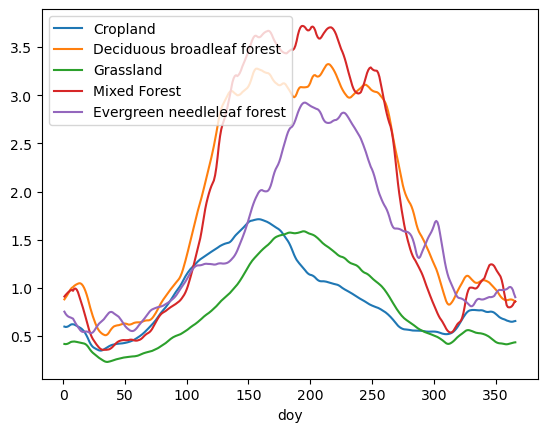

In [17]:
lai_veg_cycles_df.plot()